# Task 1: Uniswap Hedging

## Code Imports

In [1]:
include("./Uniswap/src/Uniswap.jl")
using Latexify, DataFrames, TidierData, Plots

## Introduction

Users interested in utilizing AMMs on Uniswap do need to hedge their position if they want to hold a delta neutral position. [Zhang et. all](https://arxiv.org/abs/2208.06046) describes the current industry standards regarding analyzing market maker delta hedging strategies by describing LVR and utilizing stochastics to properly price AMM positions as options. Also [Lambert](https://lambert-guillaume.medium.com/how-to-deploy-delta-neutral-liquidity-in-uniswap-or-why-euler-finance-is-a-game-changer-for-lps-1d91efe1e8ac) has generated an excellent overview of this for concentrated liquidity positions.

As asked by the task, the below code shows a created library to determine Uniswap states for V2, and describing hedging methods noted by both Zhang and Lambert.

## Code

Uniswap v2 is defined by a reserves invariant, and an equation that gives the current marginal price assuming a small swap. As swap sizes get larger, one can use the reserves invariant to compute the true price per swap.

In [2]:
latexify(Uniswap.PoolSolvers.v2Invariant)

L"\begin{equation}
\mathtt{liquidity}^{2} = \mathtt{token0} \mathtt{token1}
\end{equation}
"

In [3]:
latexify(Uniswap.PoolSolvers.swapInvariant)

L"\begin{equation}
\mathtt{liquidity}^{2} = \left( \mathtt{swapAmount0} + \mathtt{token0} \right) \left( \mathtt{swapAmount1} + \mathtt{token1} \right)
\end{equation}
"

The Uniswap PoolSolvers module holds relevant code that will help in this analysis, but it's main tool is utilizing these invariants and solving to model pool state at target prices or tvl amounts. The code is not shown here for brevity but can be seen in the included files.

### Portfolio Value Changes with Price

Using the created Uniswap Library, we can interpolate prices, pool states, and values for a pool with a fixed liquidity amount.

Some assumptions made are that the liquidity is not updating during price changes, and the user is not receiving fees. The goal is to generate a hedging strategy from the data model of pool states.

To initialize the pool, I am assuming a price of 3800 USD for ETH with 37M tvl in the pool, which is close to current prices at the time of this writing. Also for modeling, the code initializes the user funds at 1000 USD of total capital already entered in the pool. We will see in the final table the user will have 0.131579 ETH and 500 USD(C/T) if they hold 1000 USD in the pool.

In [4]:
initial_capital::Real = 1000;
initial_price::Real = 3800;
pool_prices = initial_price+400:-50:initial_price-400;
initial_dollar::Real = 18500000;
initial_token::Real = initial_dollar / initial_price;

starting_pool_state = Uniswap.PoolSolvers.UniswapV2PoolState(initial_dollar, initial_token);
starting_pool_finances = Uniswap.UniswapV2PoolFinances(starting_pool_state);
initial_pool_tvl = starting_pool_finances.tvl;
initial_pool_perc = initial_capital / (2 *starting_pool_state.amountDollar);

pool_states = map(price -> Uniswap.PoolSolvers.UniswapV2PoolPriceUpdate(starting_pool_state, price), pool_prices);
pool_finances = map(st -> Uniswap.PoolSolvers.UniswapV2PoolFinances(st), pool_states);

To view the states more cleanly, the below code organizes the data into a table to easily see the pool values and user state across pool price changes.

In [5]:
rawdf = DataFrame(
    prices=pool_prices,
    token_vals= map(st -> st.amountToken, pool_states),
    dollar_vals= map(st -> st.amountDollar, pool_states),
    tvl= map(st -> st.tvl, pool_finances),
    pool_perc= initial_pool_perc
);
df = @chain rawdf begin
    @mutate(
        position_token  = token_vals  * !!initial_pool_perc,
        position_dollar = dollar_vals * !!initial_pool_perc
    )
    @mutate(
        position_value = position_token * prices + position_dollar
    )
    @mutate(
        dollar_loss_user = !!initial_capital - position_value,
        dollar_loss_pool = !!initial_pool_tvl - tvl
    )
    @mutate(
        perc_loss_user = dollar_loss_user / !!initial_capital,
        perc_loss_pool = dollar_loss_pool / !!initial_pool_tvl,
        perc_price_change = (!!initial_price - prices) / !!initial_price
    )
end;

@chain df begin
    @select(prices, position_value, perc_loss_user)
end

Row,prices,position_value,perc_loss_user
,Int64,Float64,Float64
1,4200,1051.31,-0.051315
2,4150,1045.04,-0.0450384
3,4100,1038.72,-0.0387239
4,4050,1032.37,-0.0323708
5,4000,1025.98,-0.0259784
6,3950,1019.55,-0.0195458
7,3900,1013.07,-0.0130725
8,3850,1006.56,-0.00655745
9,3800,1000.0,0.0


## Hedging Strategies

The key point from the data, is also the main thesis in the LVR paper by Zhang. One does need to short the exact token amount at each price point with a frequency, but because the token amount increases as price drops, users must dynamic hedge. Because the portfolio value in percent changes _slower_ than the price, one needs to do dynamic hedging and update their short amount with a frequency that reduces exposure to the volatile asset.

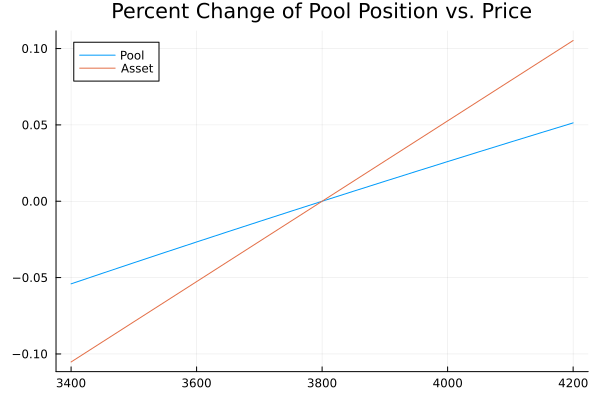

In [6]:
p = plot(df.prices, -df.perc_loss_user, label="Pool")

plot!(df.prices, -df.perc_price_change, label="Asset", title="Percent Change of Pool Position vs. Price")

Specifically, at the start of the position, the user has 0.131579 ETH and 500 USD (see the first row of the dataframe). To hedge, they must hold a short of 0.131 ETH. As the price goes down, the user's short will cover the loss of the pool as the asset price is lower than the pool value.

The problem is if the pool increases in price and the user is short, as then the asset value increases faster than the pool value, and they will lose more money in the short. As discussed in Lambert and Zhang, the appropriate strategy is to "rebalance" by picking a specific frequency, and closing your short to exactly match the pool's token assets. This means increasing your short as the price drops, and decreasing your short as the price increases.

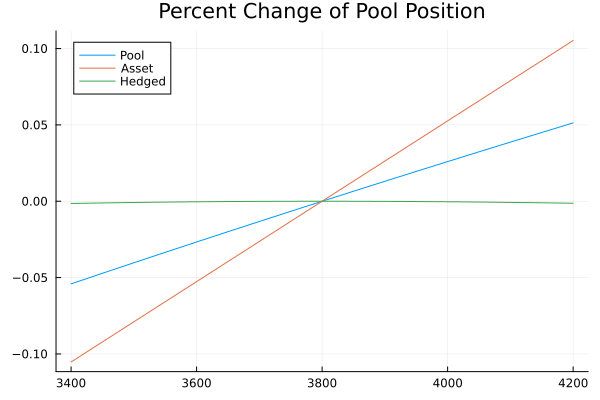

In [7]:
hedged_df = @chain df begin
    @mutate(
        short_hedge_value  = !!0.131579 * (!!initial_price - prices),
    )
    @mutate(
        hedged_port_value = position_value + short_hedge_value 
    )
    @mutate(
        perc_loss_user_hedged = (!!initial_capital - hedged_port_value) / !!initial_capital,
    )
end;

p2 = plot(hedged_df.prices, -hedged_df.perc_loss_user, label="Pool")
plot!(hedged_df.prices, -hedged_df.perc_price_change, label="Asset")
plot!(hedged_df.prices, -hedged_df.perc_loss_user_hedged, label="Hedged", title="Percent Change of Pool Position")

Note the problem, if the short position is held, the short losses outweight the pool asset's price increase. Looking at the dataframe, the user is not perfectly hedged as their portfolio's loss is positive. Below is a table position showing the portfolio value, the hedged portfolio value including the short, and the percent loss of the hedged portfolio.

In [8]:
@chain hedged_df begin
    @select(position_value, hedged_port_value, perc_loss_user_hedged)
end

Row,position_value,hedged_port_value,perc_loss_user_hedged
,Float64,Float64,Float64
1,1051.31,998.683,0.00131663
2,1045.04,998.986,0.00101425
3,1038.72,999.25,0.000749787
4,1032.37,999.476,0.000523948
5,1025.98,999.663,0.000337448
6,1019.55,999.809,0.000191027
7,1013.07,999.915,8.54497e-5
8,1006.56,999.978,2.15027e-5
9,1000.0,1000.0,0.0


## Conclusion

The main goal of this was to highlight a strategy to hedge a uniswap at a specific time. It is clear the closest hedging method is to purchase a short option on the amount of token in the pool. The code also shows a main issue highlighted in previous research, as the pool's assets are volatile and changing, one must dynamically hedge an amount that matches the pool reserves, otherwise they will still collect losses.

Zhang and Lambert describe this process is magnified with Uniswap Concentrated liquidity positions. When using those protocols, users must aggresively dynamically hedge at a high frequency (at least every day), where one closes the previous day's shorts and reopens to cover the protocol's reserve amount in tokens.

This post ignores short costs such as premiums or funding rates, as well as earned fees. An active topic of discussion is whether this can be profitable since one needs to earn enough fees earned in the pool to cover the cost of dynamic shorting, which motivated the creation of Panoptic, a protocol which allows users to short the position itself and receive a yield swap for a fixed rate instead of a position's variable rate.

A recommended strategy is to utilize OTM European options rather than a perpetual short for both V2 and CL positions to minimize costs, while absorbing some possible losses if the price does not move out of range.